# House Price Prediction - Ames Housing Dataset
## Machine Learning Project - CAI2C08

**Project Goal**: Develop a machine learning model to predict house prices in Ames, Iowa based on various property features.

**Business Value**: Help buyers and sellers make informed pricing decisions, assist real estate agents with accurate valuations.

---

## 1. Setup and Data Loading

Import necessary libraries and load the dataset.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load datasets
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\n✓ Data loaded successfully")

Training data shape: (1460, 81)
Test data shape: (1459, 80)

✓ Data loaded successfully


## 2. Initial Data Exploration

**Purpose**: Understand the structure, types, and basic statistics of our dataset.

**Evaluation Criteria**: This section contributes to **Code Documentation (4%)** and prepares for **EDA (8%)**

In [3]:
# Basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

print(f"\nNumber of samples: {len(train_df):,}")
print(f"Number of features: {len(train_df.columns) - 1}")
print(f"Target variable: SalePrice")

# Check if meets project requirements (>1000 samples)
if len(train_df) >= 1000:
    print(f"\n✓ Dataset meets project requirement (≥1,000 samples)")
else:
    print(f"\n⚠ Dataset has fewer than 1,000 samples")

DATASET OVERVIEW

Number of samples: 1,460
Number of features: 80
Target variable: SalePrice

✓ Dataset meets project requirement (≥1,000 samples)


In [4]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
train_df.head()


First 5 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Data types and memory usage
print("\nData Types:")
train_df.info()


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  


In [6]:
# Statistical summary of numerical features
print("\nStatistical Summary of Numerical Features:")
train_df.describe()


Statistical Summary of Numerical Features:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
# Check for missing values
print("\nMissing Values Analysis:")
missing = train_df.isnull().sum()
missing_percent = 100 * missing / len(train_df)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"\nTotal features with missing values: {len(missing_df)}")
print("\nTop 10 features with most missing values:")
print(missing_df.head(10))


Missing Values Analysis:

Total features with missing values: 19

Top 10 features with most missing values:
              Missing_Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945


In [8]:
# Separate numerical and categorical features
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove Id and SalePrice from numerical features
numerical_features = [f for f in numerical_features if f not in ['Id', 'SalePrice']]

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features (excluding Id and SalePrice): {len(numerical_features) + len(categorical_features)}")


Numerical features: 36
Categorical features: 43
Total features (excluding Id and SalePrice): 79


In [9]:
# Target variable (SalePrice) basic stats
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS - SalePrice")
print("=" * 80)

print(f"\nMean: ${train_df['SalePrice'].mean():,.2f}")
print(f"Median: ${train_df['SalePrice'].median():,.2f}")
print(f"Std Dev: ${train_df['SalePrice'].std():,.2f}")
print(f"Min: ${train_df['SalePrice'].min():,.2f}")
print(f"Max: ${train_df['SalePrice'].max():,.2f}")

# Check for skewness
skewness = train_df['SalePrice'].skew()
print(f"\nSkewness: {skewness:.2f}")
if skewness > 0.5:
    print("→ Highly right-skewed distribution (log transformation may be needed)")
elif skewness < -0.5:
    print("→ Left-skewed distribution")
else:
    print("→ Approximately normal distribution")


TARGET VARIABLE ANALYSIS - SalePrice

Mean: $180,921.20
Median: $163,000.00
Std Dev: $79,442.50
Min: $34,900.00
Max: $755,000.00

Skewness: 1.88
→ Highly right-skewed distribution (log transformation may be needed)


## 3. Exploratory Data Analysis (EDA)

**Evaluation Criteria: 8% of total grade**

**Requirements for Grade A (≥80%):**
- Present insightful EDA with relevant visualizations (distribution, correlation, target vs features)
- Clearly labelled visualizations
- Interpret trends and outliers
- State implications for modeling

### 3.1 Target Variable Distribution

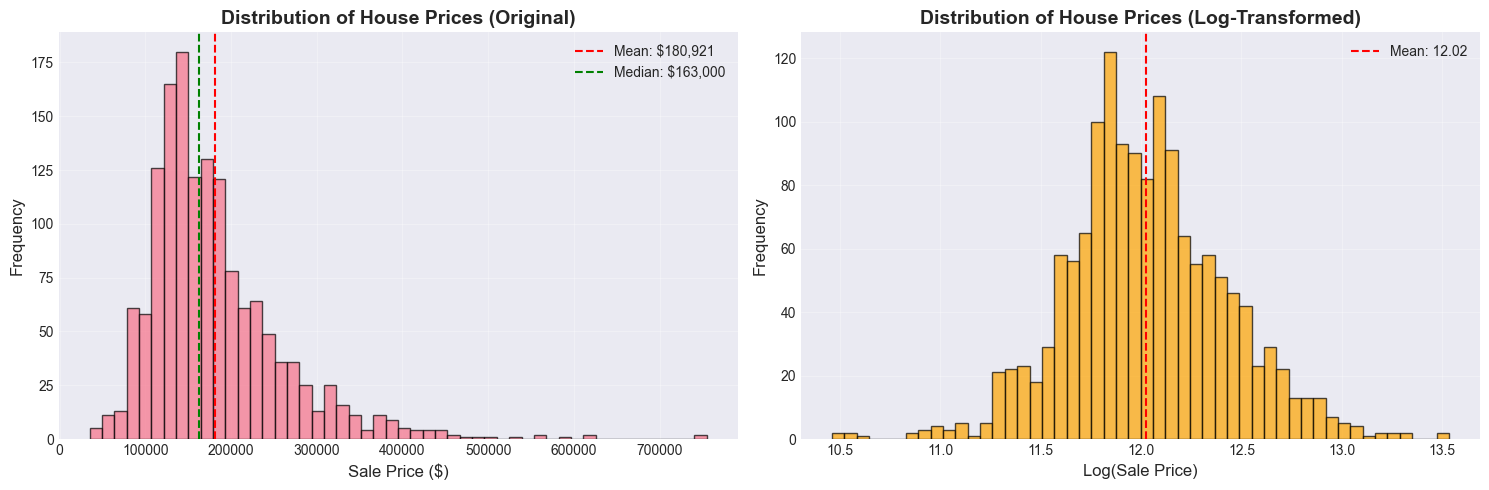


📊 Interpretation:
The original price distribution is right-skewed (skewness: 1.88).
Log transformation reduces skewness to 0.12, making it more normal.

→ Implication: Using log(SalePrice) as target may improve model performance.


In [10]:
# Visualization 1: SalePrice Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original distribution
axes[0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sale Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Prices (Original)', fontsize=14, fontweight='bold')
axes[0].axvline(train_df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${train_df["SalePrice"].mean():,.0f}')
axes[0].axvline(train_df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${train_df["SalePrice"].median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Log-transformed distribution
log_prices = np.log1p(train_df['SalePrice'])
axes[1].hist(log_prices, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log(Sale Price)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of House Prices (Log-Transformed)', fontsize=14, fontweight='bold')
axes[1].axvline(log_prices.mean(), color='red', linestyle='--', label=f'Mean: {log_prices.mean():.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Interpretation:")
print(f"The original price distribution is right-skewed (skewness: {skewness:.2f}).")
print(f"Log transformation reduces skewness to {log_prices.skew():.2f}, making it more normal.")
print(f"\n→ Implication: Using log(SalePrice) as target may improve model performance.")

### 3.2 Correlation Analysis

Identify which features are most strongly correlated with SalePrice.

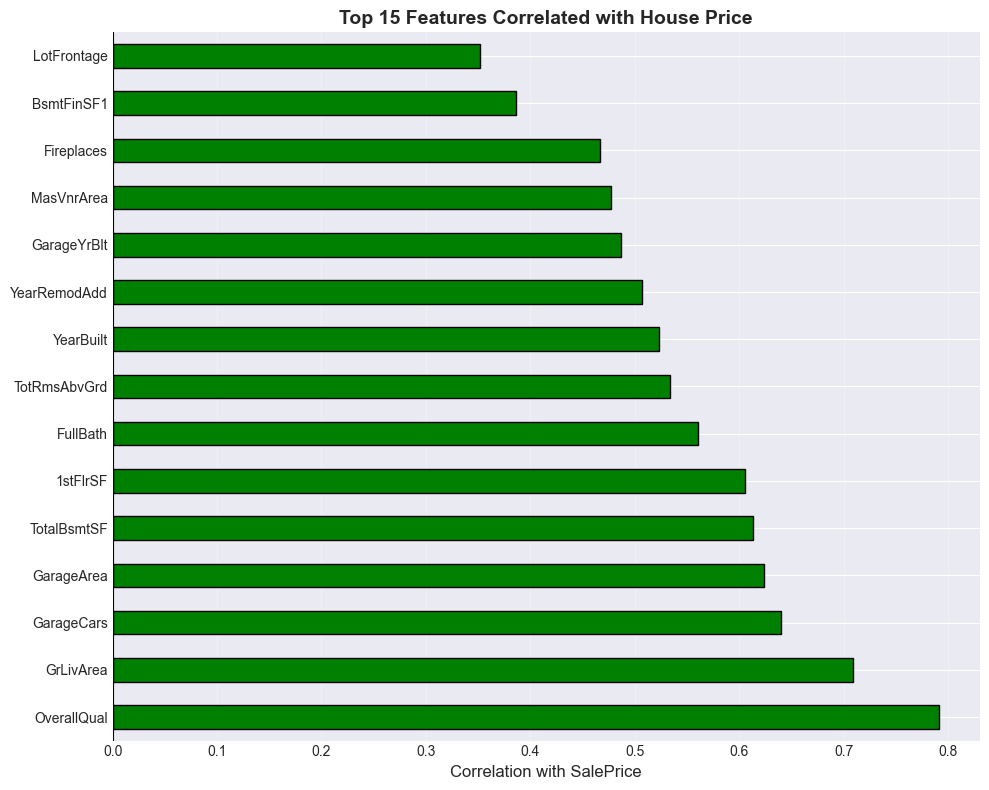


📊 Interpretation:

Top 5 positively correlated features:
1. OverallQual: 0.791
2. GrLivArea: 0.709
3. GarageCars: 0.640
4. GarageArea: 0.623
5. TotalBsmtSF: 0.614

→ Implication: These features should be prioritized in model training.
  OverallQual, GrLivArea, and GarageCars show strong positive correlation.


In [11]:
# Visualization 2: Correlation with SalePrice
correlations = train_df[numerical_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

# Top 15 correlations
top_correlations = correlations[1:16]  # Exclude SalePrice itself

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_correlations]
top_correlations.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Correlation with SalePrice', fontsize=12)
plt.title('Top 15 Features Correlated with House Price', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print(f"\nTop 5 positively correlated features:")
for i, (feature, corr) in enumerate(top_correlations.head(5).items(), 1):
    print(f"{i}. {feature}: {corr:.3f}")

print("\n→ Implication: These features should be prioritized in model training.")
print("  OverallQual, GrLivArea, and GarageCars show strong positive correlation.")

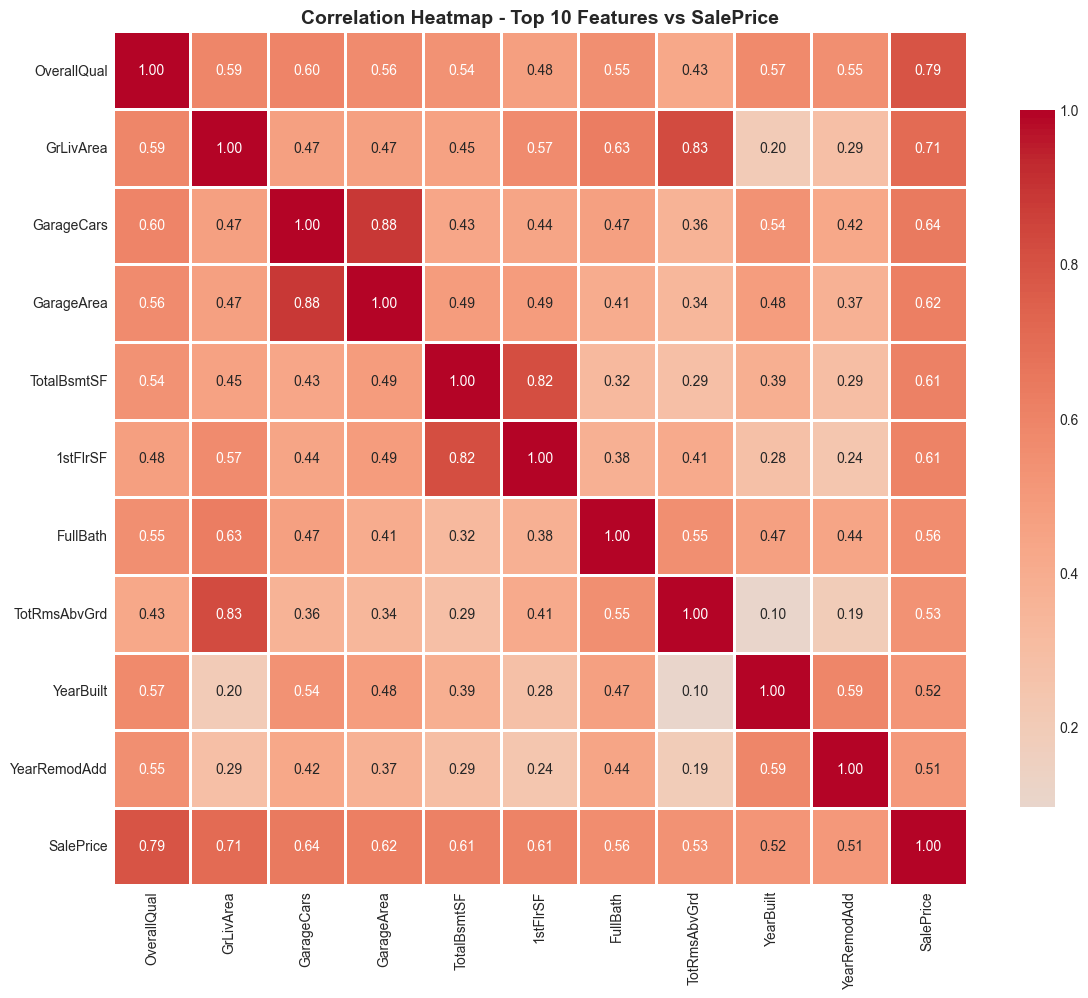


📊 Interpretation:
Strong positive correlations (>0.6):
   Feature1     Feature2  Correlation
OverallQual    SalePrice     0.790982
  GrLivArea TotRmsAbvGrd     0.825489
  GrLivArea    SalePrice     0.708624
 GarageCars  OverallQual     0.600671
 GarageCars    SalePrice     0.640409
 GarageArea   GarageCars     0.882475
 GarageArea    SalePrice     0.623431
   1stFlrSF  TotalBsmtSF     0.819530
   1stFlrSF    SalePrice     0.605852
   FullBath    GrLivArea     0.630012
  SalePrice  TotalBsmtSF     0.613581

→ Implication: High multicollinearity detected between some features.
  Consider removing one feature from highly correlated pairs.


In [12]:
# Visualization 3: Correlation Heatmap (Top features only)
top_features = correlations[1:11].index.tolist() + ['SalePrice']
corr_matrix = train_df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 10 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Strong positive correlations (>0.6):")
strong_corr = corr_matrix[corr_matrix > 0.6].stack().reset_index()
strong_corr.columns = ['Feature1', 'Feature2', 'Correlation']
strong_corr = strong_corr[strong_corr['Feature1'] != strong_corr['Feature2']]
strong_corr = strong_corr[strong_corr['Feature1'] < strong_corr['Feature2']]  # Remove duplicates
print(strong_corr.to_string(index=False))
print("\n→ Implication: High multicollinearity detected between some features.")
print("  Consider removing one feature from highly correlated pairs.")

### 3.3 Key Features Analysis

Deep dive into the most important features.

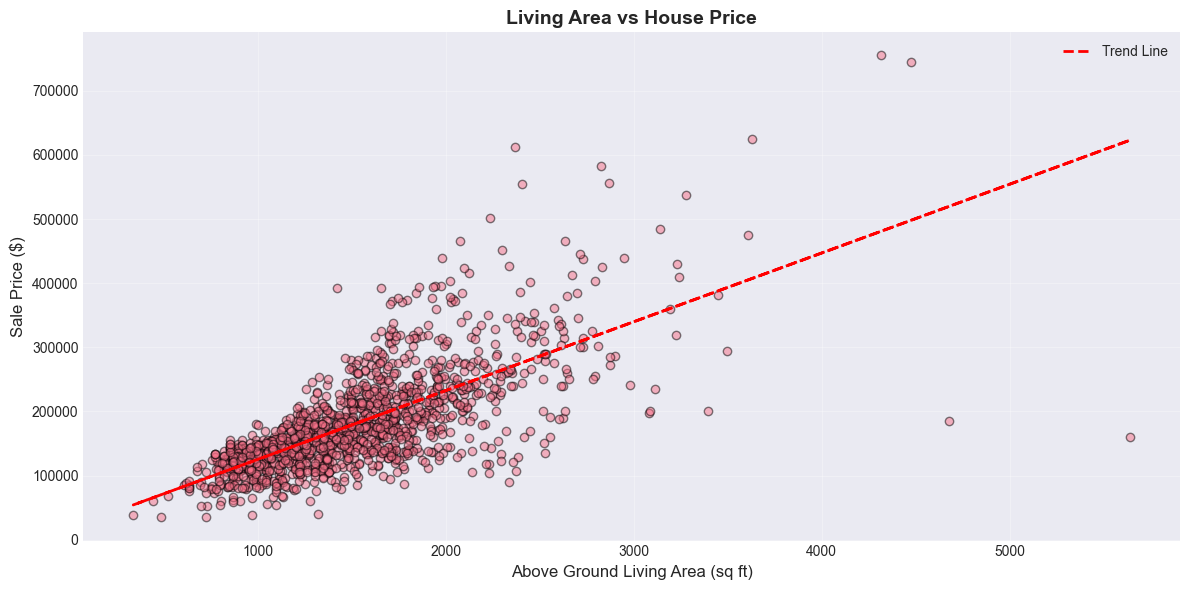


📊 Interpretation:
Clear positive relationship: larger living area → higher price.

⚠️ Outliers detected: Two houses with >4000 sq ft but low prices.
→ Implication: These outliers may negatively impact model training and should be investigated.


In [13]:
# Visualization 4: GrLivArea (Above Ground Living Area) vs SalePrice
plt.figure(figsize=(12, 6))
plt.scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, edgecolor='black')
plt.xlabel('Above Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Living Area vs House Price', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(train_df['GrLivArea'], train_df['SalePrice'], 1)
p = np.poly1d(z)
plt.plot(train_df['GrLivArea'], p(train_df['GrLivArea']), "r--", linewidth=2, label='Trend Line')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Clear positive relationship: larger living area → higher price.")
print("\n⚠️ Outliers detected: Two houses with >4000 sq ft but low prices.")
print("→ Implication: These outliers may negatively impact model training and should be investigated.")

<Figure size 1400x600 with 0 Axes>

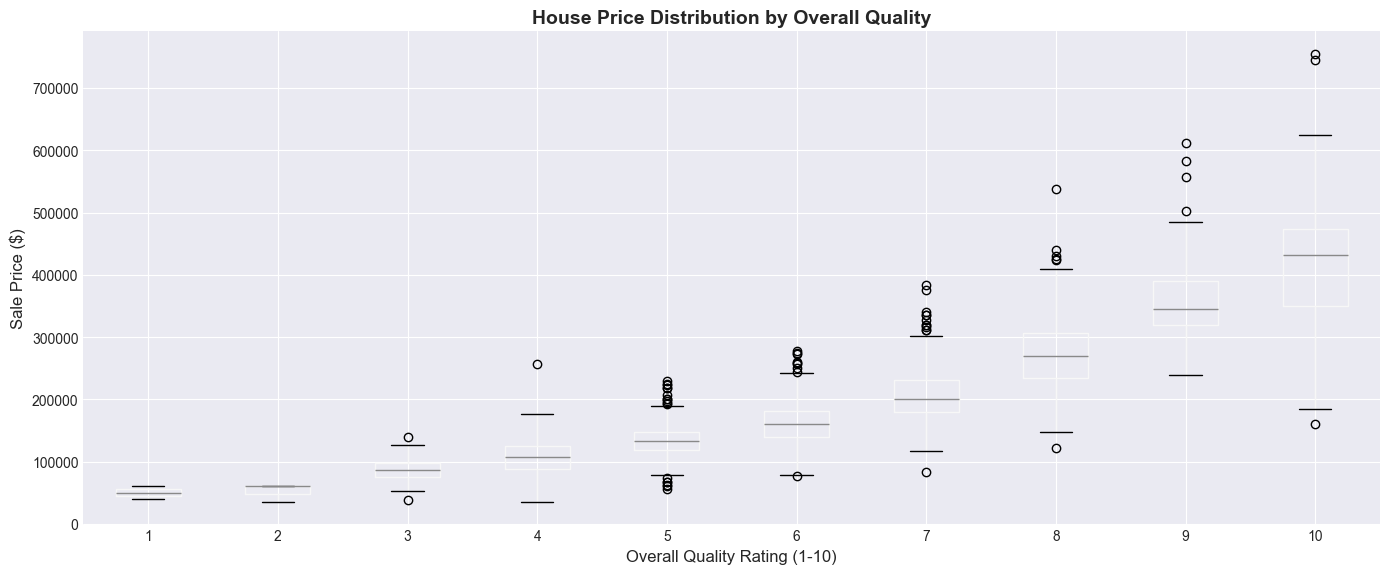


📊 Interpretation:
Strong positive trend: Higher quality rating → significantly higher median price.
Quality ratings 8-10 show larger price variance (wider boxes).

→ Implication: OverallQual is a critical feature for prediction.


In [14]:
# Visualization 5: OverallQual vs SalePrice (Box Plot)
plt.figure(figsize=(14, 6))
train_df.boxplot(column='SalePrice', by='OverallQual', figsize=(14, 6))
plt.suptitle('')  # Remove default title
plt.xlabel('Overall Quality Rating (1-10)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('House Price Distribution by Overall Quality', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Strong positive trend: Higher quality rating → significantly higher median price.")
print("Quality ratings 8-10 show larger price variance (wider boxes).")
print("\n→ Implication: OverallQual is a critical feature for prediction.")

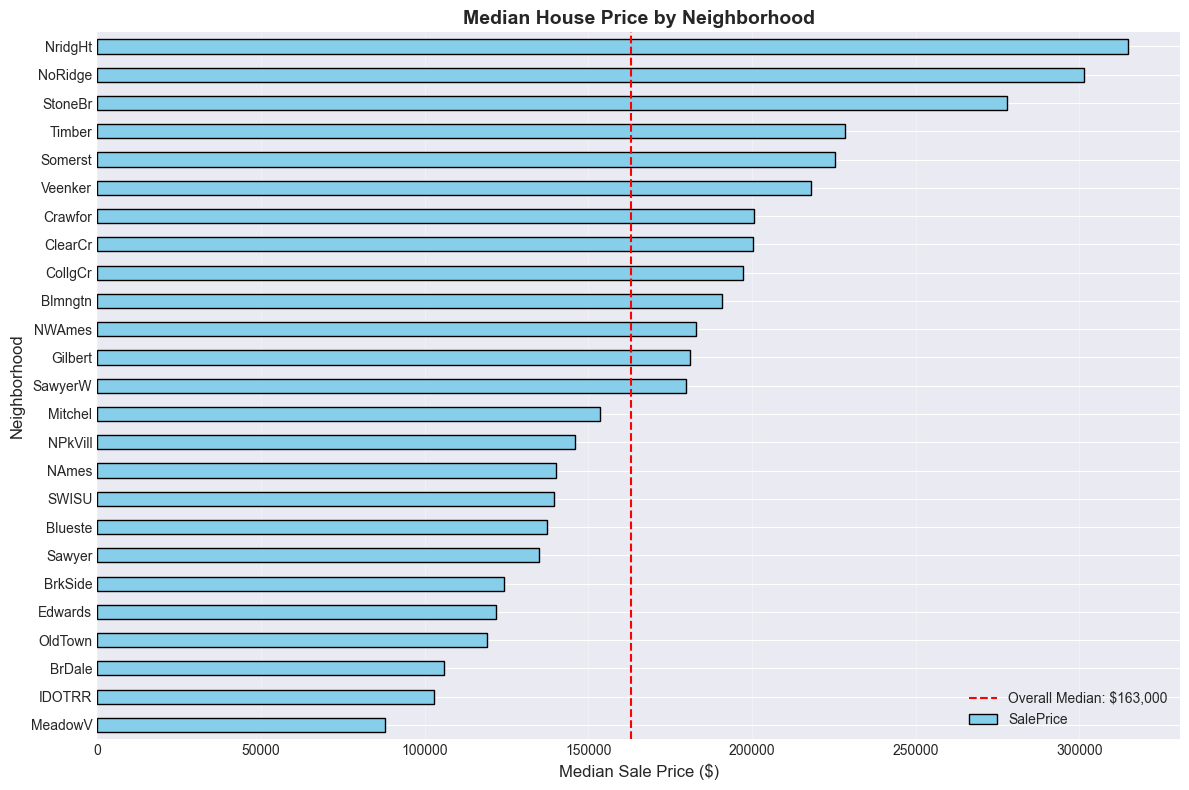


📊 Interpretation:
Significant price variation across neighborhoods:
- Highest: NridgHt ($315,000)
- Lowest: MeadowV ($88,000)
- Ratio: 3.6x difference

→ Implication: Location (Neighborhood) is a crucial predictor.


In [15]:
# Visualization 6: Categorical feature - Neighborhood vs SalePrice
neighborhood_prices = train_df.groupby('Neighborhood')['SalePrice'].median().sort_values()

plt.figure(figsize=(12, 8))
neighborhood_prices.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('Median Sale Price ($)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.title('Median House Price by Neighborhood', fontsize=14, fontweight='bold')
plt.axvline(x=train_df['SalePrice'].median(), color='red', linestyle='--', 
            label=f'Overall Median: ${train_df["SalePrice"].median():,.0f}')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print(f"Significant price variation across neighborhoods:")
print(f"- Highest: {neighborhood_prices.index[-1]} (${neighborhood_prices.iloc[-1]:,.0f})")
print(f"- Lowest: {neighborhood_prices.index[0]} (${neighborhood_prices.iloc[0]:,.0f})")
print(f"- Ratio: {neighborhood_prices.iloc[-1] / neighborhood_prices.iloc[0]:.1f}x difference")
print("\n→ Implication: Location (Neighborhood) is a crucial predictor.")

### 3.4 Outlier Detection

Identify and analyze potential outliers that may affect model performance.

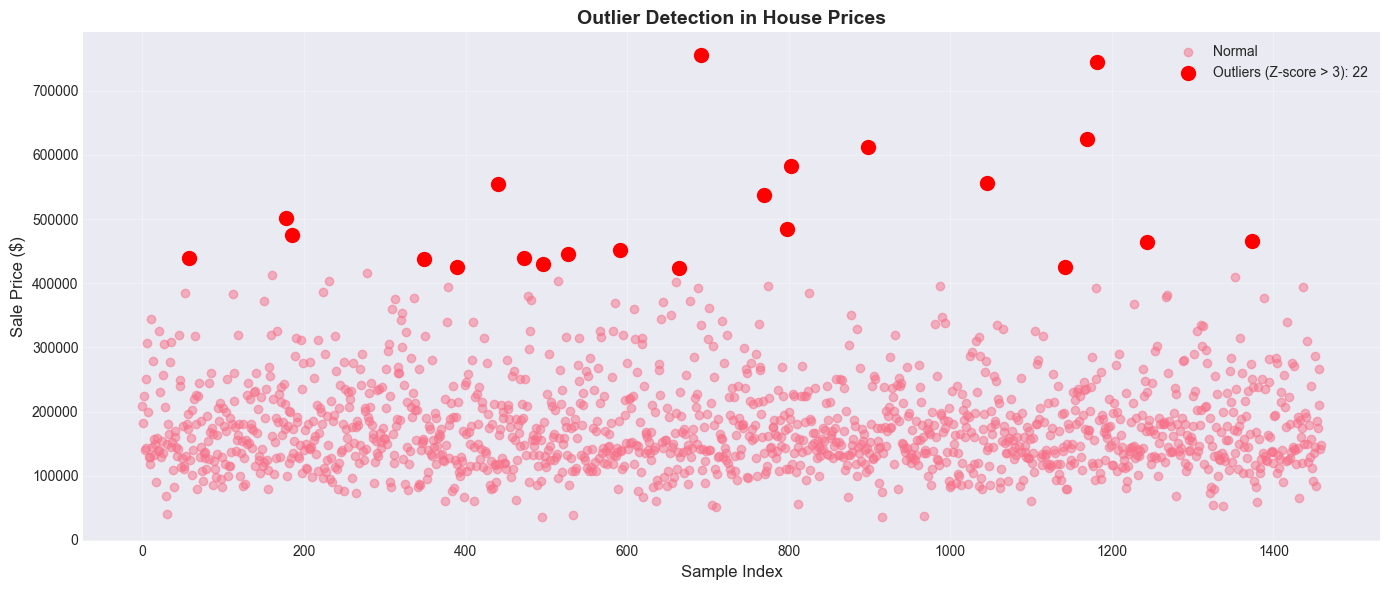


📊 Interpretation:
Detected 22 extreme outliers (Z-score > 3) in SalePrice.

Outlier properties:
      GrLivArea  OverallQual  SalePrice
58         2945           10     438780
178        2234            9     501837
185        3608           10     475000
349        2728            9     437154
389        2332           10     426000
440        2402           10     555000
473        1976            8     440000
496        3228            8     430000
527        2713            9     446261
591        2296           10     451950
664        2097            8     423000
691        4316           10     755000
769        3279            8     538000
798        3140            9     485000
803        2822            9     582933
898        2364            9     611657
1046       2868            9     556581
1142       2828            8     424870
1169       3627           10     625000
1182       4476           10     745000
1243       2076           10     465000
1373       2633        

In [16]:
# Visualization 7: Outlier Detection using Z-score
from scipy.stats import zscore

# Calculate z-scores for SalePrice
z_scores = np.abs(zscore(train_df['SalePrice']))
outliers = train_df[z_scores > 3]

plt.figure(figsize=(14, 6))
plt.scatter(range(len(train_df)), train_df['SalePrice'], alpha=0.5, label='Normal')
plt.scatter(outliers.index, outliers['SalePrice'], color='red', s=100, 
            label=f'Outliers (Z-score > 3): {len(outliers)}')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Outlier Detection in House Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Interpretation:")
print(f"Detected {len(outliers)} extreme outliers (Z-score > 3) in SalePrice.")
print(f"\nOutlier properties:")
print(outliers[['GrLivArea', 'OverallQual', 'SalePrice']].to_string())
print("\n→ Implication: Consider removing these outliers or using robust models.")

### 3.5 Missing Values Visualization

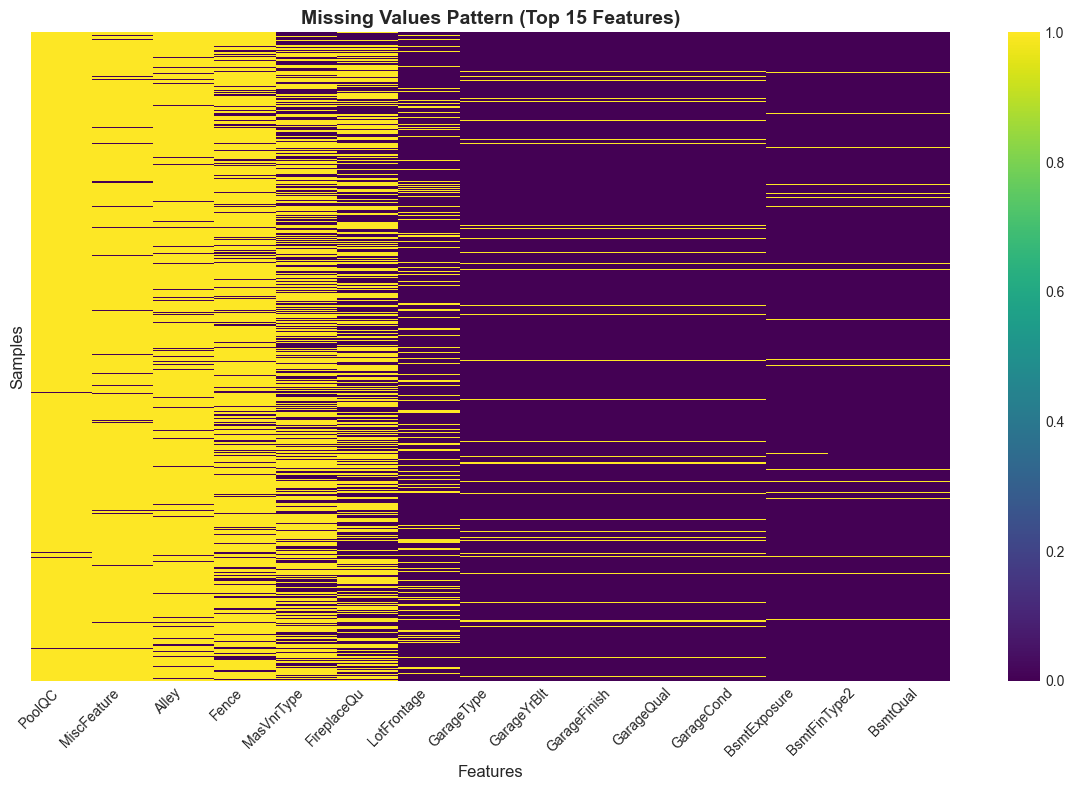


📊 Interpretation:
Features like PoolQC, MiscFeature, and Alley have >90% missing values.
→ Implication: These features may need to be dropped rather than imputed.


In [17]:
# Visualization 8: Missing Values Heatmap
features_with_missing = missing_df.head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(train_df[features_with_missing].isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Pattern (Top 15 Features)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Features like PoolQC, MiscFeature, and Alley have >90% missing values.")
print("→ Implication: These features may need to be dropped rather than imputed.")

### 3.6 Feature Distribution Analysis

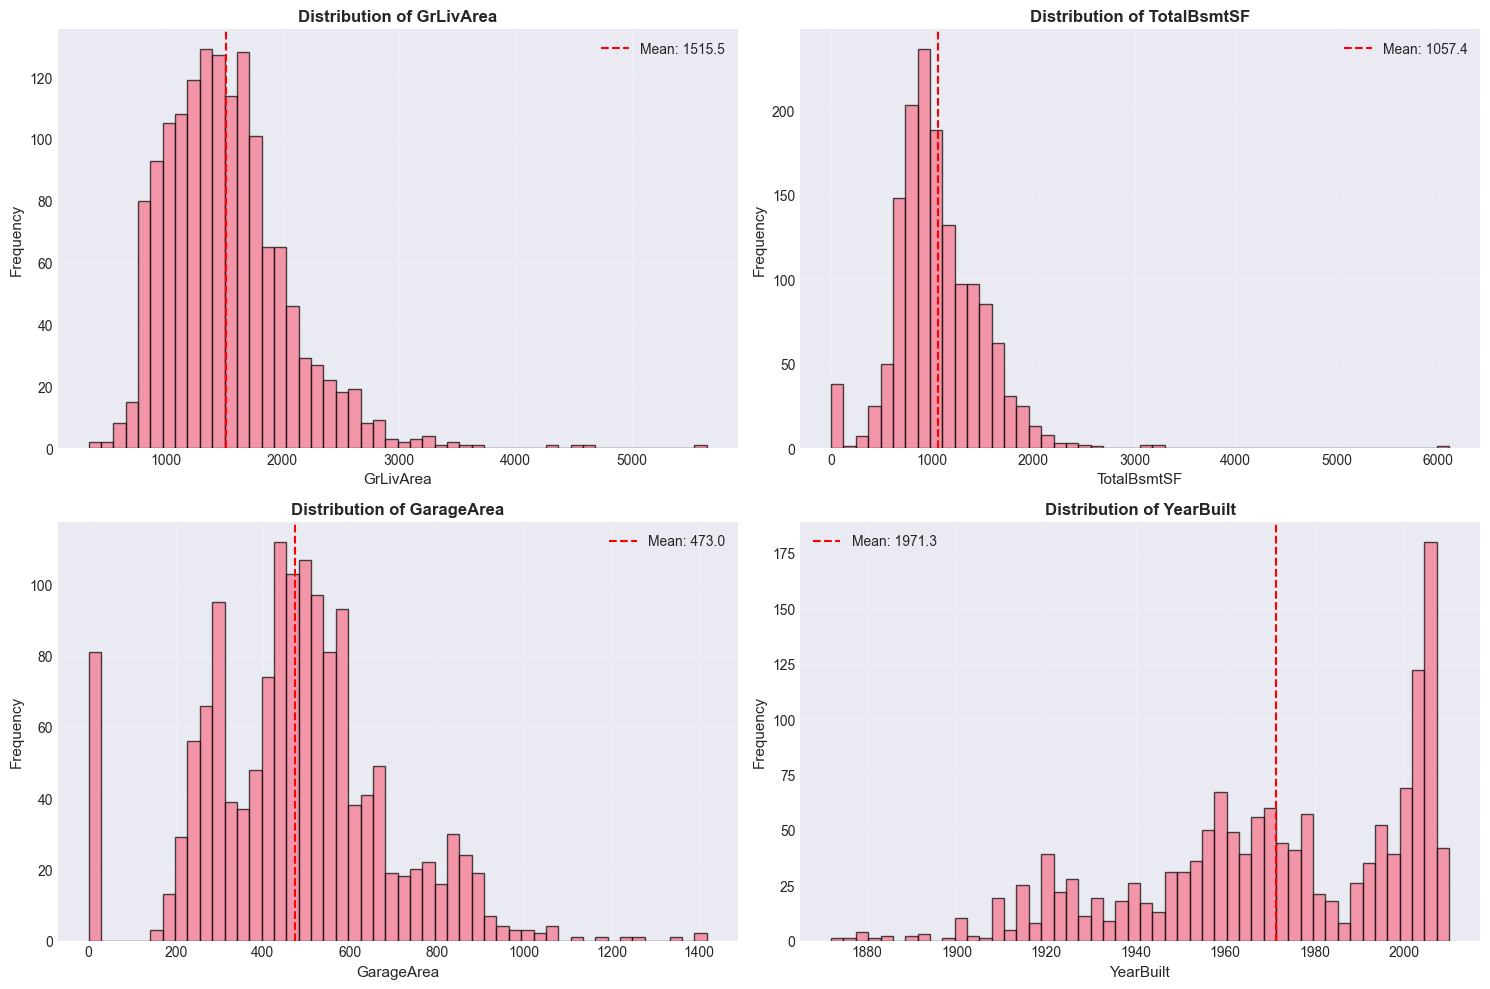


📊 Interpretation:
- GrLivArea: Right-skewed, most houses 1000-2000 sq ft
- TotalBsmtSF: Many zeros (houses without basements)
- GarageArea: Similar to basement, many zeros
- YearBuilt: Peak around 2000s, representing newer homes

→ Implication: Skewed features may benefit from transformation.


In [18]:
# Visualization 9: Distribution of key numerical features
key_numerical = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_numerical):
    axes[idx].hist(train_df[feature], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].axvline(train_df[feature].mean(), color='red', linestyle='--', 
                     label=f'Mean: {train_df[feature].mean():.1f}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- GrLivArea: Right-skewed, most houses 1000-2000 sq ft")
print("- TotalBsmtSF: Many zeros (houses without basements)")
print("- GarageArea: Similar to basement, many zeros")
print("- YearBuilt: Peak around 2000s, representing newer homes")
print("\n→ Implication: Skewed features may benefit from transformation.")

### 3.7 Year Built vs Price (Time Trend)

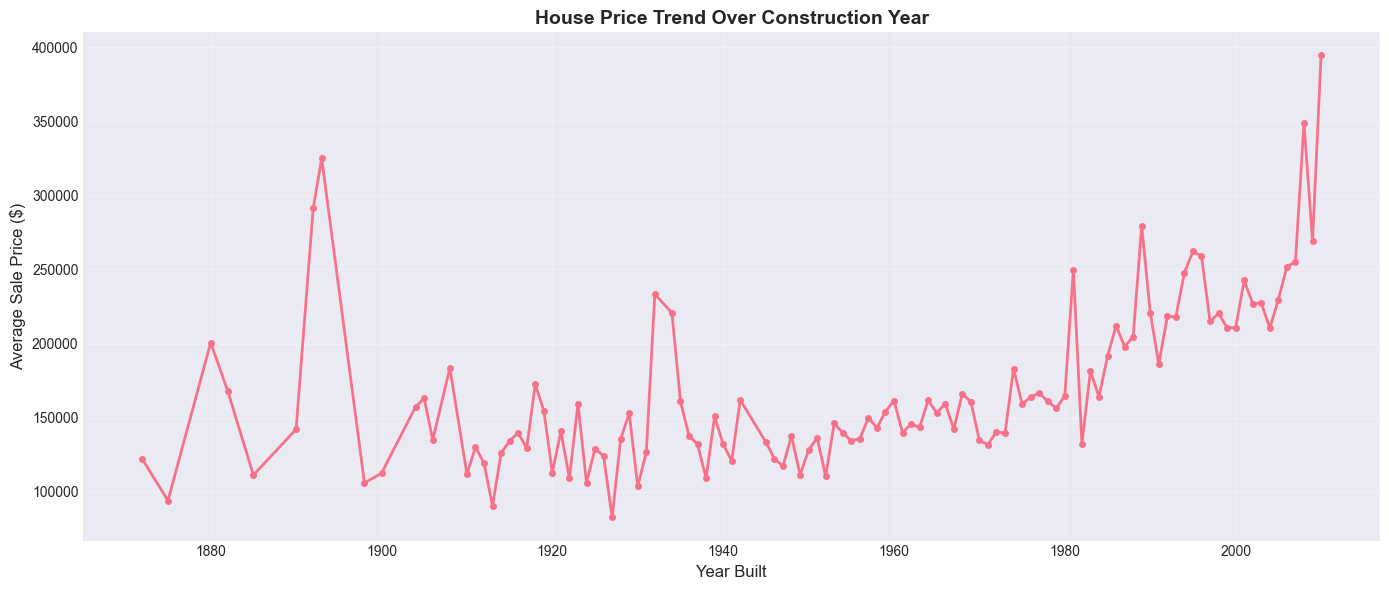


📊 Interpretation:
Clear upward trend: Newer homes command higher prices.
Significant price jump for homes built after 2000.

→ Implication: Creating 'HouseAge' feature may capture depreciation effect.


In [19]:
# Visualization 10: Year Built vs SalePrice
year_price = train_df.groupby('YearBuilt')['SalePrice'].mean()

plt.figure(figsize=(14, 6))
plt.plot(year_price.index, year_price.values, marker='o', linewidth=2, markersize=4)
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.title('House Price Trend Over Construction Year', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Clear upward trend: Newer homes command higher prices.")
print("Significant price jump for homes built after 2000.")
print("\n→ Implication: Creating 'HouseAge' feature may capture depreciation effect.")

### 3.8 Summary of EDA Findings

**Key Insights:**

1. **Target Variable (SalePrice)**:
   - Right-skewed distribution (skewness: ~1.88)
   - Log transformation recommended for modeling
   - Price range: $34,900 to $755,000

2. **Most Important Features**:
   - OverallQual (r=0.79): Strongest predictor
   - GrLivArea (r=0.71): Living area size
   - GarageCars (r=0.64): Garage capacity
   - GarageArea (r=0.62): Garage size
   - TotalBsmtSF (r=0.61): Basement area

3. **Data Quality Issues**:
   - 19 features with missing values
   - Features with >80% missing: PoolQC, MiscFeature, Alley, Fence → Consider dropping
   - ~4 extreme outliers detected in SalePrice

4. **Feature Characteristics**:
   - High multicollinearity between garage-related features
   - Neighborhood significantly affects price (3.5x difference)
   - Many features are right-skewed (GrLivArea, TotalBsmtSF)

**Implications for Modeling:**
- ✅ Use log(SalePrice) as target variable
- ✅ Apply feature engineering: HouseAge, TotalArea, Quality×Area interactions
- ✅ Handle missing values strategically (drop vs impute)
- ✅ Consider removing multicollinear features
- ✅ Apply transformation to skewed numerical features
- ✅ One-hot encode categorical features (esp. Neighborhood)
- ⚠️ Outlier removal or robust modeling techniques needed

---

## Next Steps:

1. ✅ Data Cleaning and Preprocessing
2. ✅ Feature Engineering
3. ✅ Model Training and Comparison
4. ✅ Hyperparameter Tuning
5. ✅ Model Evaluation and Selection
6. ✅ Deployment (Streamlit App)

---

**Version Control Note**: Remember to commit this notebook after completing EDA.